# CIBUSmod Scenario example:<br/>Revisiting scenarios for organic farming in Sweden

This notebook provides an example run of CIBUSmod using two scenarios up until 2050; 'Base20' and 'Sust50' originally developed by Basnet *et al.* (2023).

**Base20:** A business-as-ususal scenario with assumptions on productivity improvements and population growth   
**Sust50:** A scenario with increased organic production (up to 50% of cropland) coupled with stronger productivity gains, reduced food waste and dietary changes towards less animal-source foods


Basnet, S., Wood, A., Röös, E., Jansson, T., Fetzer, I. & Gordon, L. (2023). Organic agriculture in a low-emission world: exploring combined measures to deliver a sustainable food system in Sweden. *Sustainability Science*, 18(1), 501-519. https://doi.org/10.1007/s11625-022-01279-9

## Set things up

Add directory with the CIBUSmod modules to path to be able to import

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(),'..'))

Import CIBUSmod and packages for handling data and plotting

In [2]:
import CIBUSmod as cm
import CIBUSmod.utils.plot as plot

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Instantiate a `Session` object and define scenarios.

In [3]:
years = list(range(2020,2050+1,5))

# Create session
session = cm.Session(
    name = 'example_scenarios',
    data_path = '../data'
)

# Define scenarios
session.add_scenario(
    name = 'Base20',
    scenario_workbooks = 'example_bau',
    years = years
)

# Define scenarios
session.add_scenario(
    name = 'Sust50',
    scenario_workbooks = ['example_bau', 'example_org_circ'],
    years = years
)

A scenario with the name 'Base20' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'Sust50' already exists use .update_scenario() or .remove_scenario() instead.


Define some styling for plots

In [4]:
bar_style = {
    'ticklabels_fontsize' : 9,
    'grouplabels_fontsize' : 9,
    'ylabel_fontsize' : 10,
    'xlabel_fontsize' : 10,
    'cmap' : 'YlGnBu'
}

def annotate_axs(axs, size=10, offset=(-3,1)):
    import string
    for i, ax in enumerate(axs.flatten()):
        ax.annotate(
            f'({string.ascii_lowercase[i % 26]})',
            xy = (0,1), xycoords = 'axes fraction',
            xytext = offset, textcoords = 'offset fontsize',
            fontsize=size, fontweight='bold', va='bottom', ha='right'
        )

def cat7_cmap():
    from matplotlib.colors import ListedColormap
    colors = [
        "#2c7fb8",
        "#f03b20",
        "#31a354",
        "#a1dab4",
        "#fecc5c",
        "#ffffcc",
        "#ffffff",
    ]
    cmap_name = "cat7"
    cmap = ListedColormap(colors, name=cmap_name)
    return cmap

## Run calculations
The code below initiates a process pool that executes the model runs. The `max_workers` paramter to `ProcessPoolExecutor()` defines the maximum number of concurrent processes. The ideal value for this will depend on the computer. The code will print a message every time a scenario run has finnished and if a scenario run fails it will print an error message.

In [5]:
# Import
from concurrent.futures import ProcessPoolExecutor, as_completed
from multi_proc import do_run
import traceback

# Create list of scenarios/years to run
runs = [(s,y) for s, y in session.iterate('2025-08-27')]
runs

[('Base20', '2020'),
 ('Base20', '2025'),
 ('Base20', '2030'),
 ('Base20', '2035'),
 ('Base20', '2040'),
 ('Base20', '2045'),
 ('Base20', '2050'),
 ('Sust50', '2020'),
 ('Sust50', '2025'),
 ('Sust50', '2030'),
 ('Sust50', '2035'),
 ('Sust50', '2040'),
 ('Sust50', '2045'),
 ('Sust50', '2050')]

In [6]:
%%time

# Do the multi-processing
with ProcessPoolExecutor(max_workers=8) as executor:
    
    futures = {executor.submit(do_run, session, scn_year) : scn_year for scn_year in runs}

    for future in as_completed(futures):
    
        scn, year = futures[future]
           
        try:
            t = future.result()
        except Exception as ee:
            print(f'(!!!) {scn}, {year} failed with the exception: {ee}')
        else:
            m = int(t/60)
            s = int(round(t - m*60))
            
            print(f'{scn}, {year} finished successfully in {m}min {s}s')

session.cache.clear()

Base20, 2020 finished successfully in 5min 16s
Base20, 2040 finished successfully in 5min 20s
Base20, 2030 finished successfully in 5min 28s
Base20, 2050 finished successfully in 5min 38s
Base20, 2045 finished successfully in 5min 50s
Sust50, 2020 finished successfully in 5min 53s
Base20, 2035 finished successfully in 5min 55s
Base20, 2025 finished successfully in 6min 5s
Sust50, 2025 finished successfully in 4min 0s
Sust50, 2030 finished successfully in 4min 4s
Sust50, 2040 finished successfully in 4min 29s
Sust50, 2035 finished successfully in 4min 51s
Sust50, 2050 finished successfully in 4min 29s
Sust50, 2045 finished successfully in 4min 35s
CPU times: total: 109 ms
Wall time: 10min 32s


## Plot output

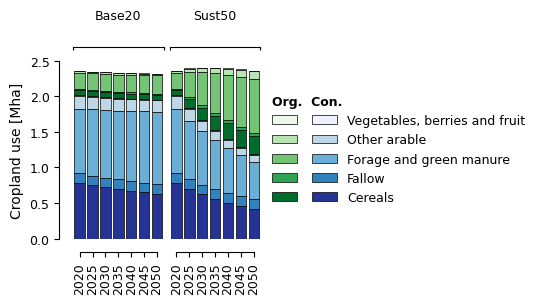

Share of cropland:


prod_system  conventional    organic  total
scn    year                                
Base20 2020     85.608559  14.391441  100.0
       2025     85.315835  14.684165  100.0
       2030     85.056485  14.943515  100.0
       2035     84.824746  15.175254  100.0
       2040     84.601062  15.398938  100.0
       2045     84.388531  15.611469  100.0
       2050     84.195950  15.804050  100.0
Sust50 2020     85.589742  14.410258  100.0
       2025     76.596616  23.403384  100.0
       2030     69.430674  30.569326  100.0
       2035     63.403628  36.596372  100.0
       2040     58.290223  41.709777  100.0
       2045     53.904191  46.095809  100.0
       2050     50.084210  49.915790  100.0

Total cropland area:


prod_system  conventional   organic     total
scn    year                                  
Base20 2020      2.014817  0.338706  2.353523
       2025      2.001759  0.344533  2.346292
       2030      1.988953  0.349438  2.338391
       2035      1.975879  0.353487  2.329367
       2040      1.966197  0.357884  2.324080
       2045      1.959084  0.362421  2.321506
       2050      1.951235  0.366258  2.317492
Sust50 2020      2.014660  0.339197  2.353857
       2025      1.830213  0.559205  2.389418
       2030      1.667475  0.734165  2.401641
       2035      1.522411  0.878731  2.401141
       2040      1.395608  0.998633  2.394241
       2045      1.283744  1.097785  2.381529
       2050      1.182315  1.178339  2.360654

Share "Forage and green manure":


prod_system  conventional    organic
scn    year                         
Base20 2020     45.276952  66.453583
       2025     46.565467  67.124541
       2030     47.762855  67.721628
       2035     48.897710  68.268947
       2040     49.976515  68.790847
       2045     51.010739  69.286096
       2050     51.984057  69.745661
Sust50 2020     45.273474  66.493847
       2025     45.177920  63.577374
       2030     45.104913  63.407825
       2035     45.009972  63.574416
       2040     44.945472  63.835084
       2045     44.944574  64.116796
       2050     45.000835  64.415236

Share "Cereals":


prod_system  conventional    organic
scn    year                         
Base20 2020     38.554868  20.976749
       2025     37.315518  20.636879
       2030     36.171898  20.335571
       2035     35.102938  20.058718
       2040     34.099994  19.798576
       2045     33.150806  19.554226
       2050     32.263117  19.325723
Sust50 2020     38.557447  20.952053
       2025     37.923185  22.352682
       2030     37.293756  22.478035
       2035     36.699121  22.496292
       2040     36.111995  22.481343
       2045     35.504344  22.436875
       2050     34.894237  22.346843

In [5]:
plot_data = (
    session.get_attr('c','area',{'prod_system':None, 'crop':['land_use','crop_group2']})
    .loc[:,(slice(None),'cropland')]
    .droplevel('land_use', axis=1)
    .rename(columns={'Fodder crops':'Forage and green manure'})
)/1_000_000

from matplotlib.colors import ListedColormap
colors = ['#253494', '#3182bd', '#6baed6','#bdd7e7' , '#eff3ff',
          '#006d2c', '#31a354', '#74c476', '#bae4b3', '#edf8e9']
cust_cmap = ListedColormap(name='X', colors=colors)

# Hide crop group for organic to make nice legend
plot_data_ = plot_data.copy()
plot_data_.columns = \
pd.MultiIndex.from_tuples(
    [(ps,cg) if ps != 'organic' else (ps,' ') for ps,cg in plot_data_.columns],
    names = plot_data_.columns.names
)

fig, ax = plt.subplots(figsize=(5.5,3))
cm.plot.bar(
    plot_data_.droplevel('prod_system', axis=1),
    ax=ax,
    group_levels='scn',
    sort_categories=False,
    ylabel='Cropland use [Mha]',
    **{k:v for k,v in bar_style.items() if k != 'cmap'},
    cmap=cust_cmap,
    ylim=(0,2.5)
)
ax.legend(
    loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=2, frameon=False, reverse=True, fontsize=9,
    columnspacing = 0.1,
    title='Org.  Con.',
    title_fontproperties={'weight': 'bold', 'size': 9},  # Make title bold and adjust size
    alignment="left"  # Align legend text to the left
)

plt.tight_layout()
plt.savefig('figs/mp2025/Fig10.png', dpi=300)
plt.savefig('figs/mp2025/Fig10.pdf', dpi=300)
plt.show()

tab_data = plot_data.T.groupby('prod_system').sum().T
tab_data['total'] = tab_data.sum(axis=1)
tab_data2 = plot_data.T.groupby('prod_system').apply(lambda x: x/x.sum()*100).T.droplevel(0, axis=1)

print('Share of cropland:')
display(tab_data.apply(lambda x: x/x.total*100, axis=1))
print('Total cropland area:')
display(tab_data)
print('Share "Forage and green manure":')
display(tab_data2.xs('Forage and green manure', level='crop_group2', axis=1))
print('Share "Cereals":')
display(tab_data2.xs('Cereals', level='crop_group2', axis=1))

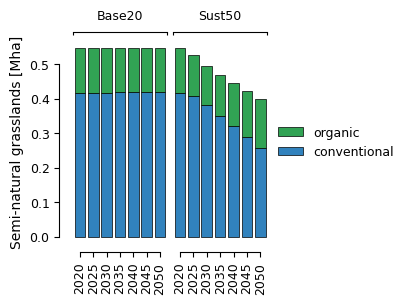

In [6]:
plot_data = (
    session.get_attr('c','area',{'prod_system':None, 'crop':'land_use'})
    .loc[:,(slice(None),'semi-natural grasslands')]
    .droplevel('land_use', axis=1)
)/1_000_000

from matplotlib.colors import ListedColormap
colors = ['#3182bd','#31a354']
cust_cmap = ListedColormap(name='X', colors=colors)

fig, ax = plt.subplots(figsize=(2.5,2.5))
cm.plot.bar(
    plot_data,
    ax=ax,
    group_levels='scn',
    sort_categories=False,
    ylabel='Semi-natural grasslands [Mha]',
    **{k:v for k,v in bar_style.items() if k != 'cmap'},
    cmap=cust_cmap
)
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=1, fontsize=9, frameon=False, reverse=True)
plt.show()

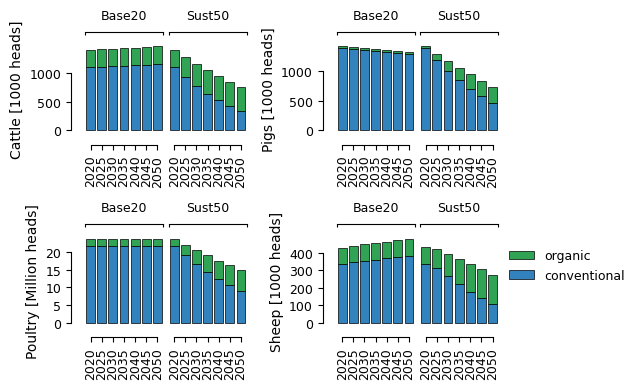

In [7]:
# Number of animal heads
plot_data = session.get_attr('A','heads',['species','prod_system'])

from matplotlib.colors import ListedColormap
colors = ['#3182bd','#31a354']
cust_cmap = ListedColormap(name='X', colors=colors)

fig, axs = plt.subplots(2,2, figsize=(6.5,4))

for ax,sp in zip(axs.flatten(),plot_data.drop('horses', axis=1).columns.get_level_values('species').unique()):

    cm.plot.bar(
        (plot_data / (1000000 if sp=='poultry' else 1000))
        .xs(sp, level='species', axis=1),
        **{k:v for k,v in bar_style.items() if k != 'cmap'},
        cmap=cust_cmap,
        ax=ax,
        group_levels='scn',
        ylabel=sp.capitalize() + (' [Million heads]' if sp=='poultry' else ' [1000 heads]')
    )

for ax in axs.flatten():
    ax.legend().set_visible(False)
ax.legend(loc='upper left', ncol=1, bbox_to_anchor=(1, 1), fontsize=9, frameon=False, reverse=True)

plt.tight_layout()
plt.show()

In [8]:
d = (
    session.get_attr('c','harvest',{'crop':['land_use',None],'prod_system':None})/
    session.get_attr('c','area',{'crop':['land_use',None],'prod_system':None})
).loc[[('Base20','2020'),('Base20','2050'),('Sust50','2050')],'cropland'] / 1_000

display(d.T.xs('conventional', level='prod_system', drop_level=False))
display(d.T.xs('organic', level='prod_system', drop_level=False))

scn                                                  Base20             \
year                                                   2020       2050   
crop                                prod_system                          
Apples                              conventional  18.327680  21.196677   
Barley, spring                      conventional   5.008122   5.969669   
Barley, winter                      conventional   6.368804   7.585717   
Beans, dry                          conventional   1.771584   1.769239   
Broad beans and horse beans, dry    conventional   3.288674   4.123439   
Buckwheat                           conventional   1.947419   1.549989   
Cabbages, cauliflowers and broccoli conventional  21.635853  27.035069   
Carrots                             conventional  67.397426  85.546550   
Cereals for fodder                  conventional   3.492757   3.496864   
Cucumbers                           conventional  61.768979   6.080620   
Currants                            conventional   1.475338   1.498246   
Energy grass                        conventional   4.026117   4.027126   
Fallow                              conventional        NaN        NaN   
Green manure                        conventional        NaN        NaN   
Herbs                               conventional   4.008418   5.097607   
Lettuce and spinach                 conventional  15.531566  19.688001   
Ley for fodder                      conventional   5.503204   5.517508   
Ley for grazing                     conventional   4.470303   4.498272   
Ley for seed                        conventional   0.650000   0.650000   
Ley not harvested                   conventional        NaN        NaN   
Maize (corn)                        conventional   6.094953   6.099361   
Maize for forage and silage         conventional  10.807584  10.766574   
Mixed cereals                       conventional   3.325777   3.298334   
Oats                                conventional   4.618531   5.749130   
Onions                              conventional  51.294595  65.026353   
Other berries                       conventional   1.675776   1.751678   
Other crops for fodder              conventional   4.329771   4.343017   
Other fruit                         conventional   4.562669   4.583978   
Other root vegetables               conventional  34.803902  43.885569   
Other vegetables                    conventional  14.883237  18.482411   
Pears                               conventional  15.632802  15.696975   
Peas, dry                           conventional   3.409477   4.265403   
Peas, green                         conventional   4.401537   4.419005   
Potatoes, starch                    conventional  45.168759  55.110546   
Potatoes, table                     conventional  38.280820  46.619568   
Pumpkins and squash                 conventional  27.154499  34.029267   
Quinoa                              conventional   1.305022   1.305022   
Rapeseed, spring                    conventional   1.835139   2.197348   
Rapeseed, winter                    conventional   3.554972   4.260120   
Rye                                 conventional   6.902525   8.623485   
Short rotation coppice              conventional   4.694044   4.693977   
Strawberries                        conventional   6.875321   6.885965   
Sugar beet                          conventional  76.494672  95.588849   
Triticale, spring                   conventional   3.302596   3.309065   
Triticale, winter                   conventional   5.751146   5.751948   
Wheat, spring                       conventional   4.628396   6.298128   
Wheat, winter                       conventional   7.246116   9.905066   

scn                                                   Sust50  
year                                                    2050  
crop                                prod_system               
Apples                              conventional   23.834540  
Barley, spring                      conventiona

scn                                              Base20                Sust50
year                                               2020       2050       2050
crop                             prod_system                                 
Apples                           organic       8.098057   8.098096   8.067363
Barley, spring                   organic       3.169386   3.266370   4.279851
Barley, winter                   organic       3.979199   4.092991   5.006744
Beans, dry                       organic       1.401542   1.695936   1.850215
Broad beans and horse beans, dry organic       2.469416   2.876061   3.406796
Buckwheat                        organic       0.905745   0.922496   0.825086
Carrots                          organic      58.610559  74.495882  80.486336
Cereals for fodder               organic       3.084894   3.082054   3.129947
Cucumbers                        organic      10.478467  13.306564  14.432789
Energy grass                     organic       3.572877   3.567815   3.690045
Fallow                           organic            NaN        NaN        NaN
Green manure                     organic            NaN        NaN        NaN
Herbs                            organic       0.869612   1.107016   1.201931
Lettuce and spinach              organic       5.836573   7.414785   8.037394
Ley for fodder                   organic       4.729552   4.733714   4.797044
Ley for grazing                  organic       3.822981   3.839137   3.898439
Ley for seed                     organic       0.400000   0.400000   0.400000
Ley not harvested                organic            NaN        NaN        NaN
Maize (corn)                     organic       3.910108   3.909218   3.882263
Mixed cereals                    organic       2.692908   2.718541   3.054869
Oats                             organic       3.039264   3.149057   3.944235
Onions                           organic      25.811016  32.785127  35.467145
Other crops for fodder           organic       3.580754   3.585199   3.602062
Other root vegetables            organic       7.241534   9.200618   9.935477
Other vegetables                 organic       3.159573   4.014550   4.282327
Pears                            organic       5.462733   5.465184   5.437379
Peas, dry                        organic       2.517915   2.932844   3.572557
Potatoes, starch                 organic            NaN        NaN  40.518185
Potatoes, table                  organic      26.032621  31.938453  35.358049
Rapeseed, spring                 organic       0.708266   0.940198   1.143372
Rapeseed, winter                 organic       2.136516   2.828196   3.358181
Rye                              organic       3.866324   5.426498   5.955121
Short rotation coppice           organic       4.496927   4.484193   4.620642
Triticale, spring                organic       2.106280   2.107007   2.035450
Triticale, winter                organic       4.228681   4.226645   4.010731
Wheat, spring                    organic       2.913789   3.624254   4.282266
Wheat, winter                    organic       4.432683   5.526965   6.120510

scn     year
Base20  2020     0.770170
        2025     0.754804
        2030     0.741950
        2035     0.731684
        2040     0.721135
        2045     0.710863
        2050     0.702403
Sust50  2020     0.768892
        2025     3.091526
        2030     4.763189
        2035     6.213226
        2040     7.583977
        2045     8.948390
        2050    10.375732
Name: Green manure, dtype: float64

scn     year
Base20  2020    144.734033
        2025    143.408402
        2030    142.058749
        2035    140.680596
        2040    139.460590
        2045    138.360545
        2050    137.194325
Sust50  2020    144.720886
        2025    136.956868
        2030    129.692369
        2035    123.259358
        2040    117.711973
        2045    112.742305
        2050    105.528075
Name: value, dtype: float64

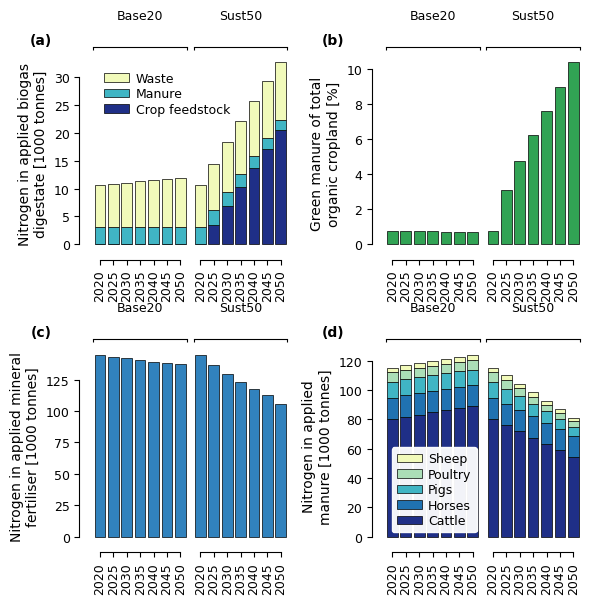

In [9]:
fig, axs = plt.subplots(2,2, figsize=(6,6))

from matplotlib.colors import ListedColormap

plot_data = (
    session.get_attr('w','organic_fertiliser_N','feedstock_type')
    .rename(columns = lambda x: 'Waste' if 'waste' in x else x.capitalize())
    .T.groupby('feedstock_type').sum().T
)/1_000_000

# fig, ax = plt.subplots(figsize=(2.5,2.5))
ax=axs[0,0]
cm.plot.bar(
    plot_data,
    ax=ax,
    group_levels='scn',
    ylabel='Nitrogen in applied biogas\ndigestate [1000 tonnes]',
    **bar_style
)
legend = ax.legend(
    loc='upper left', bbox_to_anchor=(0, 1),
    ncol=1,
    fontsize=9, handletextpad=0.5, labelspacing=0.2,
    frameon=False,
    reverse=True
)
# plt.show()

plot_data = session.get_attr('c','area',{'prod_system':None,'crop':['land_use',None]}).loc[:,('organic','cropland')].apply(lambda x: x/x.sum()*100, axis=1).loc[:,'Green manure']

colors = ['#31a354']
cust_cmap = ListedColormap(name='X', colors=colors)

# fig, ax = plt.subplots(figsize=(2.5,2.5))
ax=axs[0,1]
cm.plot.bar(
    plot_data,
    ax=ax,
    group_levels='scn',
    ylabel='Green manure of total\norganic cropland [%]',
    **{k:v for k,v in bar_style.items() if k != 'cmap'},
    cmap=cust_cmap
)
# plt.show()

display(plot_data)

plot_data = (
    session.get_attr('c','fertiliser.mineral_N','none')
)/1_000_000

colors = ['#3182bd']
cust_cmap = ListedColormap(name='X', colors=colors)

# fig, ax = plt.subplots(figsize=(2.5,2.5))
ax=axs[1,0]
cm.plot.bar(
    plot_data,
    ax=ax,
    group_levels='scn',
    ylabel='Nitrogen in applied mineral\nfertiliser [1000 tonnes]',
    **{k:v for k,v in bar_style.items() if k != 'cmap'},
    cmap=cust_cmap
)
ax.legend().set_visible(False)
# plt.show()
display(plot_data)

plot_data = (
    session.get_attr('c','fertiliser.manure_N','species')
    .rename(columns = lambda x: x.capitalize())
)/1_000_000

# fig, ax = plt.subplots(figsize=(2.5,2.5))
ax=axs[1,1]
cm.plot.bar(
    plot_data,
    ax=ax,
    group_levels='scn',
    ylabel='Nitrogen in applied\nmanure [1000 tonnes]',
    **bar_style
)
# ax.legend(loc='lower left', bbox_to_anchor=(0, 0), ncol=1, fontsize=9, frameon=True, reverse=True)
legend = ax.legend(
    loc='lower left', bbox_to_anchor=(0, 0),
    ncol=1,
    fontsize=9, handletextpad=0.5, labelspacing=0.2,
    frameon=True,
    reverse=True
)
legend.get_frame().set_edgecolor('white')
# legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(0.95)
# plt.show()

plt.tight_layout()
annotate_axs(axs)
plt.savefig('figs/mp2025/Fig12.png', dpi=300)
plt.savefig('figs/mp2025/Fig12.pdf', dpi=300)
plt.show()

In [10]:
session.get_attr('c','fertiliser.mineral_N','prod_system').add(
    session.get_attr('c','fertiliser.manure_N','prod_system')+session.get_attr('c','fertiliser.organic_N','prod_system'),
    fill_value=0
)/1_000_000

prod_system  conventional    organic
scn    year                         
Base20 2020    248.458254  22.123574
       2025    248.743966  22.502914
       2030    248.830516  22.836545
       2035    248.691053  23.123376
       2040    248.795067  23.433076
       2045    249.046399  23.751987
       2050    249.044770  24.026446
Sust50 2020    248.450983  22.133658
       2025    226.650101  34.734752
       2030    206.411467  45.804810
       2035    187.758062  55.874232
       2040    170.911306  65.055897
       2045    155.509953  73.285675
       2050    142.101622  76.981433

Base20, 2020
------------


,Manure (conv.),Manure (org.),Mineral fertiliser,Other organic fertiliser,total
prod_system,,,,,
Conventional\ncropland,40.109877,0.803694,71.756748,4.671187,117.341506
Organic\ncropland,13.758169,39.226905,NaN,3.324569,56.309644


,Manure (conv.),Manure (org.),Mineral fertiliser,Other organic fertiliser
prod_system,,,,
Conventional\ncropland,33.605155,0.673357,60.119771,3.913648
Organic\ncropland,24.286973,69.246333,NaN,5.868784


Sust50, 2050
------------


,Manure (conv.),Manure (org.),Mineral fertiliser,Other organic fertiliser,total
prod_system,,,,,
Conventional\ncropland,24.563819,0.091170,89.10055,0.000000,113.755538
Organic\ncropland,8.909135,25.467276,NaN,27.675204,62.051616


,Manure (conv.),Manure (org.),Mineral fertiliser,Other organic fertiliser
prod_system,,,,
Conventional\ncropland,21.371392,0.079321,77.520632,0.000000
Organic\ncropland,14.090055,40.277233,NaN,43.769135


C:\Users\jnka0003\AppData\Local\Temp\ipykernel_22280\95059158.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


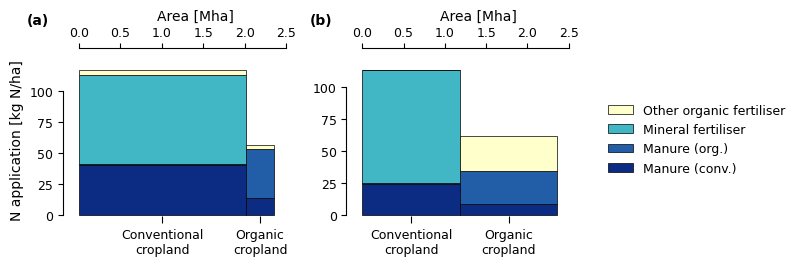

In [11]:
from matplotlib.colors import ListedColormap
colors = ['#0c2c84', '#225ea8', '#41b6c4', '#ffffcc']
cust_cmap = ListedColormap(name='X', colors=colors)

fig, axs = plt.subplots(1,2, figsize=(6.7,2), gridspec_kw={'wspace' : 0.2})

i=0
for scn, year in [('Base20','2020'),('Sust50','2050')]:

    ax = axs[i]
    
    mi = (
        session.get_attr('c','fertiliser.mineral_N',{'crop':'land_use','prod_system':None}).loc[(scn,year),'cropland']
    )
    ma = (
        session.get_attr('c','fertiliser.manure_N',{'crop':'land_use','prod_system':None, 'animal_prod_system':None}).loc[(scn,year),'cropland']
        .unstack()
        .rename(columns={'conventional':'Manure (conv.)', 'organic':'Manure (org.)'})
    )
    
    oo = (
        session.get_attr('c','fertiliser.organic_N',{'crop':'land_use','prod_system':None}).loc[(scn,year),'cropland']
    )
    
    ar = (
        session.get_attr('c','area',{'crop':'land_use', 'prod_system':None}).loc[(scn,year),'cropland']
    )
    
    plot_data = pd.concat([
        ma.div(ar, axis=0),
        mi.div(ar, axis=0).rename('Mineral fertiliser'),
        oo.div(ar, axis=0).rename('Other organic fertiliser'),
        ar.rename('area')/1_000_000
    ], axis=1).rename(index={'conventional':'Conventional\ncropland','organic':'Organic\ncropland'})
    
    cm.plot.marimekko(
        plot_data.fillna(0),
        ax=ax,
        x_column='area',
        cmap=cust_cmap,
        sort_categories=False,
        xlim_pad = 0.2,
        ylim_pad = 0.05,
        xcategorylabels_rotation=0,
        xcategorylabels_halign='center',
        ylabel='N application [kg N/ha]' if i==0 else '',
        xlabel='Area [Mha]',
        ylabel_fontsize=10,
        xlabel_fontsize=10,
        ticklabels_fontsize=9,
        xcategorylabels_fontsize=9
    )

    if i == 1:
        ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9, frameon=False, reverse=True)
    else:
        ax.legend().set_visible(False)

    table_data = plot_data.drop('area', axis=1)
    table_data['total'] = table_data.sum(axis=1)
    pstr = ', '.join((scn,year))
    print(pstr)
    print('-'*len(pstr))
    display(table_data)
    display(plot_data.div(plot_data.sum(axis=1), axis=0).drop('area', axis=1)*100)
    i += 1

plt.tight_layout()
annotate_axs(axs, offset=(-2,2.5))
plt.savefig('figs/mp2025/Fig11.png', dpi=300, bbox_inches='tight')
plt.savefig('figs/mp2025/Fig11.pdf', dpi=300, bbox_inches='tight')
plt.show()

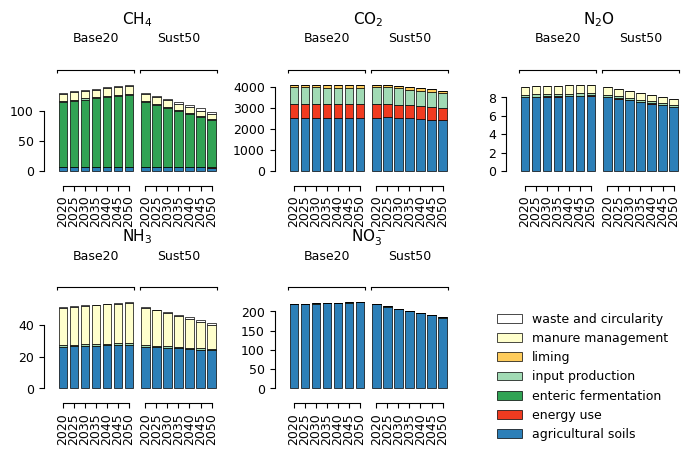

In [14]:
to_comp = {
    'CO2' : 1,
    'CH4bio' : 1,
    'CH4fos' : 1,
    'N2O' : 1,
    'N2O-N' : (44/28),
    'NH3' : 1,
    'NH3-N' : (17/14),
    'NO3-N' : (62/14),
    'NO3' : (62/14),
    'NOx' : 1,
    'NH4' : 1,
    'PO4' : 1,
    'K' : 1
}

to_comp_names = {
    'N2O' : 'N$_2$O',
    'CO2' : 'CO$_2$',
    'CH4bio' : 'CH$_4$',
    'CH4fos' : 'CH$_4$',
    'N2O-N' : 'N$_2$O',
    'NH3' : 'NH$_3$',
    'NH3-N' : 'NH$_3$',
    'NO3-N' : 'NO$_3^-$',
    'NO3' : 'NO$_3^-$',
    'NOx' : 'NO$_X$',
    'NH4' : 'NH$_4$',
    'PO4' : 'PO$_4^{3-}$',
    'K' : 'K'
}

ems = (
    cm.impact.get_emissions(session)
    .drop(['NOx-N','CO2bio','CO','N2','NOx','K','NH4','PO4','NMVOC','PM','SO2'], level='compound', axis=1)
)

plot_data = (
    ems
    .mul([to_comp[cp] for cp in ems.columns.get_level_values('compound')], axis=1)
    .rename(to_comp_names, axis=1)
    .T.groupby(['compound','process']).sum().T
    .stack().unstack().fillna(0)
)/1_000_000

fig, axs = plt.subplots(2,3, figsize=(7,4.5))
for i, cmp in enumerate(plot_data.columns.unique('compound')):
    ax = axs.flatten()[i]
    cm.plot.bar(
        plot_data.loc[:,cmp],
        group_levels='scn',
        ax=ax,
        **{k:v for k,v in bar_style.items() if k!='cmap'},
        cmap=cat7_cmap()
    )
    ax.set_title(cmp, fontsize=11)

handles, labels = ax.get_legend_handles_labels()
ax = axs.flatten()[-1]
ax.legend(handles, labels, fontsize=9, frameon=False, reverse=True)
ax.axis('off')

for ax in axs.flatten()[:-1]:
    ax.legend().set_visible(False)

plt.tight_layout()
plt.savefig('figs/mp2025/Fig13.png', dpi=300)
plt.savefig('figs/mp2025/Fig13.pdf', dpi=300)
plt.show()

tab_data = plot_data.T.groupby('compound').sum().T
display((tab_data.div(tab_data.loc[('Base20','2020')], axis=1)*100-100).style.format(precision=0))

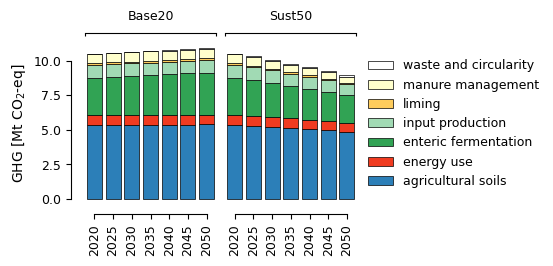

In [15]:
ghg = (
    cm.impact.get_GHG(session)
    .T.groupby('process').sum().T
) / 1_000_000_000 # [Mt]
fig, ax = plt.subplots(1,1, figsize=(3.5,2))
cm.plot.bar(
    ghg,
    group_levels='scn',
    ax=ax,
    ylabel='GHG [Mt CO$_2$-eq]',
    **{k:v for k,v in bar_style.items() if k!='cmap'},
    cmap=cat7_cmap()
)
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9, frameon=False, reverse=True)
plt.show()

tab_data = ghg.sum(axis=1).to_frame()
display((tab_data.div(tab_data.loc[('Base20','2020')], axis=1)*100-100).style.format(precision=0))

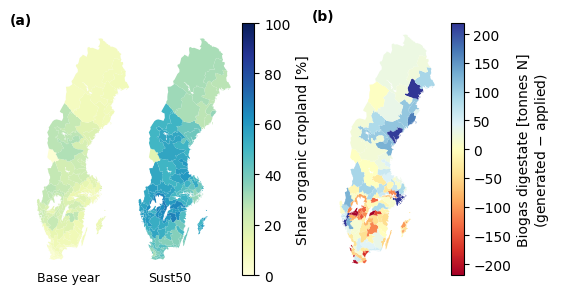

Share organic per region: 16-68%


In [16]:
plot_data1 = (
    session.get_attr('c','area',{'crop':'land_use','region':None,'prod_system':None})
    .loc[:,'cropland']
    .T.groupby('region')
    .apply(lambda x: x/x.sum()*100).xs('organic', level='prod_system')
    .droplevel(0).T
)

fig, axs = plt.subplots(1,3, figsize=(5.5,3), gridspec_kw={'width_ratios' : [1,1.25, 2.2], 'wspace' : 0})

ax=axs[0]
cm.plot.map_from_series(
    plot_data1.loc[('Sust50','2020')],
    vmin=0,
    vmax=100,
    cmap='YlGnBu',
    ax=ax,
    legend=False
)
ax.axis('off')

ax.text(0.35, 0, 'Base year', transform=ax.transAxes, 
        fontsize=9, fontweight='normal', va='top', ha='center')

ax=axs[1]
cm.plot.map_from_series(
    plot_data1.loc[('Sust50','2050')],
    vmin=0,
    vmax=100,
    cmap='YlGnBu',
    ax=ax,
    legend=False
)
ax.axis('off')

ax.text(0.35, 0, 'Sust50', transform=ax.transAxes, 
        fontsize=9, fontweight='normal', va='top', ha='center')

cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('Share organic cropland [%]', fontsize=10)

plot_data2 = (session.get_attr('w','organic_fertiliser_N','region').loc[('Sust50','2050')] - session.get_attr('c','fertiliser.organic_N','region').loc[('Sust50','2050')]) / 1_000

ax=axs[2]
cm.plot.map_from_series(
    plot_data2,
    ax = ax,
    cmap = 'RdYlBu',
    vmax = plot_data2.abs().quantile(0.95),
    vmin = -plot_data2.abs().quantile(0.95),
    legend = False
)
ax.axis('off')

cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('Biogas digestate [tonnes N]\n(generated $\minus$ applied)', fontsize=10)

plt.tight_layout()
annotate_axs(axs[[0,2]], offset=(0,0))
plt.savefig('figs/mp2025/Fig14.png', bbox_inches='tight', dpi=300)
plt.savefig('figs/mp2025/Fig14.pdf', bbox_inches='tight', dpi=300)
plt.show()

print(f"Share organic per region: {plot_data1.loc[('Sust50','2050')].min():.0f}-{plot_data1.loc[('Sust50','2050')].max():.0f}%")

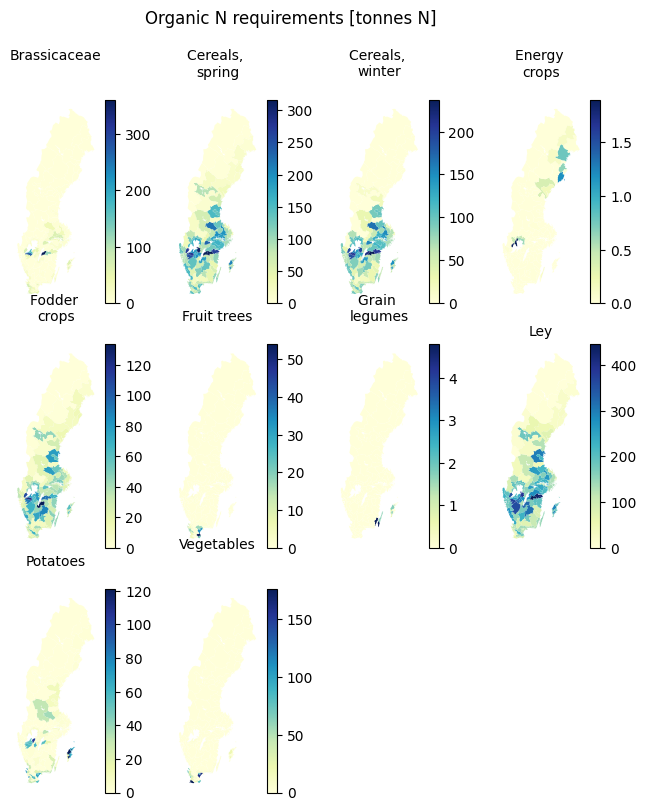

In [17]:
plot_data = (
    session.get_attr('c','fertiliser.TAN_req',{'crop':['land_use','crop_group'],'region':None,'prod_system':None})
    .xs(('cropland','organic'), level=('land_use', 'prod_system'), axis=1)
    # .T.groupby('region')
    # .apply(lambda x: x/x.sum()*100)
    # .droplevel(0).T
)/1000

fig, axs = cm.plot.subplots(
    plot_data.loc[('Sust50','2050')],
    index = 'crop_group',
    plot_fn = cm.plot.map_from_series,
    size=(2, 3),
    title_fontsize=10,
    cmap='YlGnBu'
)
for ax in axs.flatten():
    ax.axis('off')
fig.suptitle('Organic N requirements [tonnes N]')
plt.show()

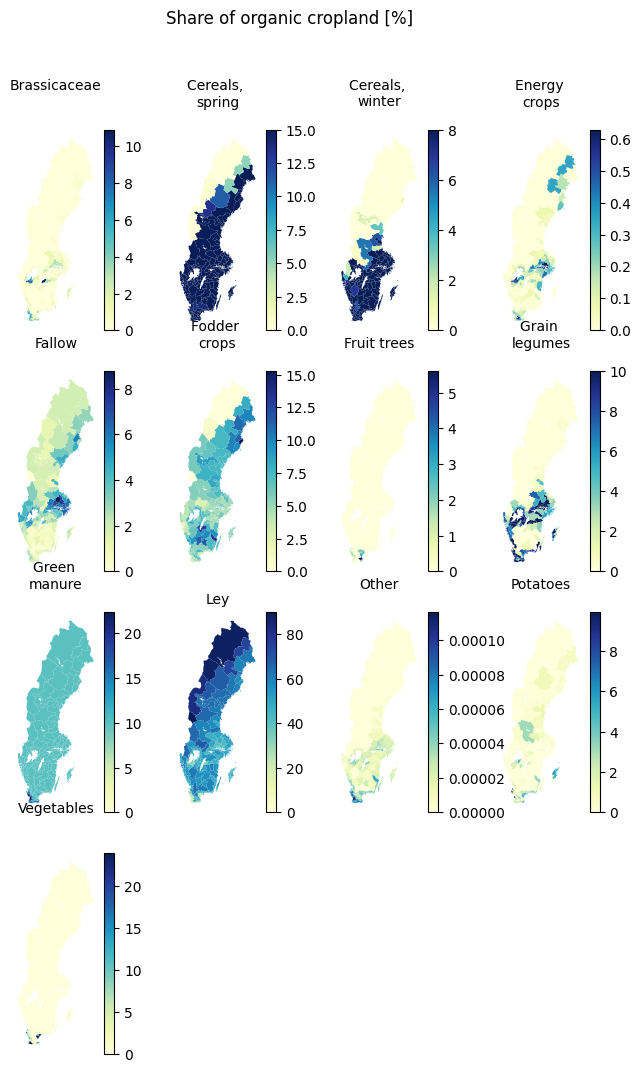

In [18]:
plot_data = (
    session.get_attr('c','area',{'crop':['land_use','crop_group'],'region':None,'prod_system':None})
    .xs(('cropland','organic'), level=('land_use', 'prod_system'), axis=1)
    .T.groupby('region')
    .apply(lambda x: x/x.sum()*100)
    .droplevel(0).T
)

fig, axs = cm.plot.subplots(
    plot_data.loc[('Sust50','2050')],
    index = 'crop_group',
    plot_fn = cm.plot.map_from_series,
    size=(2, 3),
    title_fontsize=10,
    vmin=0,
    cmap='YlGnBu'
)
for ax in axs.flatten():
    ax.axis('off')
fig.suptitle('Share of organic cropland [%]')
plt.show()

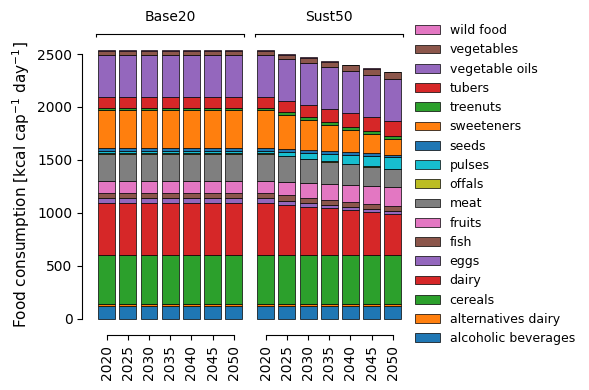

In [19]:
plot_data = (
    session.get_attr('d', 'nutrient_supply', ['nutrient','food_group'])
    .loc[:,'kcal']
    .div(
        session.get_attr('d','population')*1_000_000,
        axis=0
    )
    .div(365.25)
)

fig,ax = plt.subplots(figsize=(6,4))
cm.plot.bar(
    plot_data,
    group_levels='scn',
    ylabel='Food consumption [kcal cap$^{-1}$ day$^{-1}$]'
)

ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=1, fontsize=9, frameon=False, reverse=True)
plt.tight_layout()
plt.show()

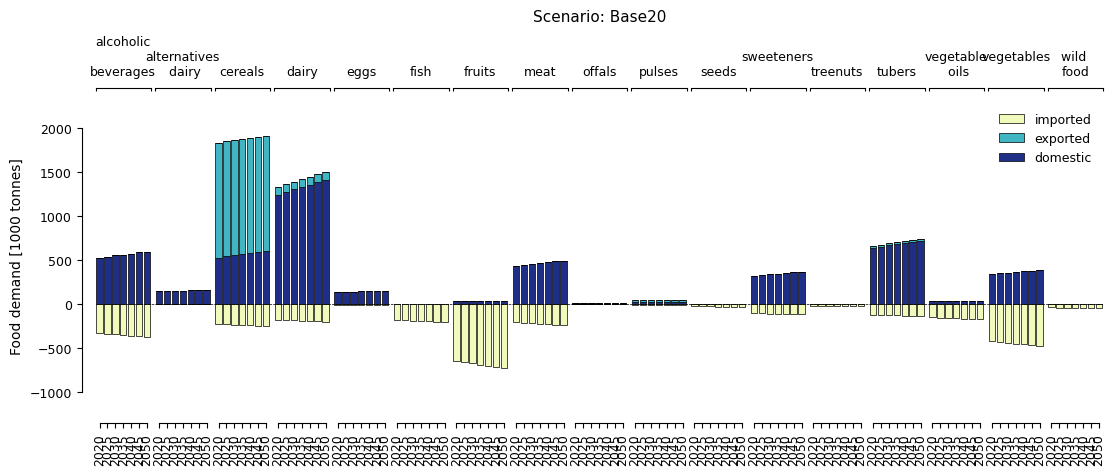

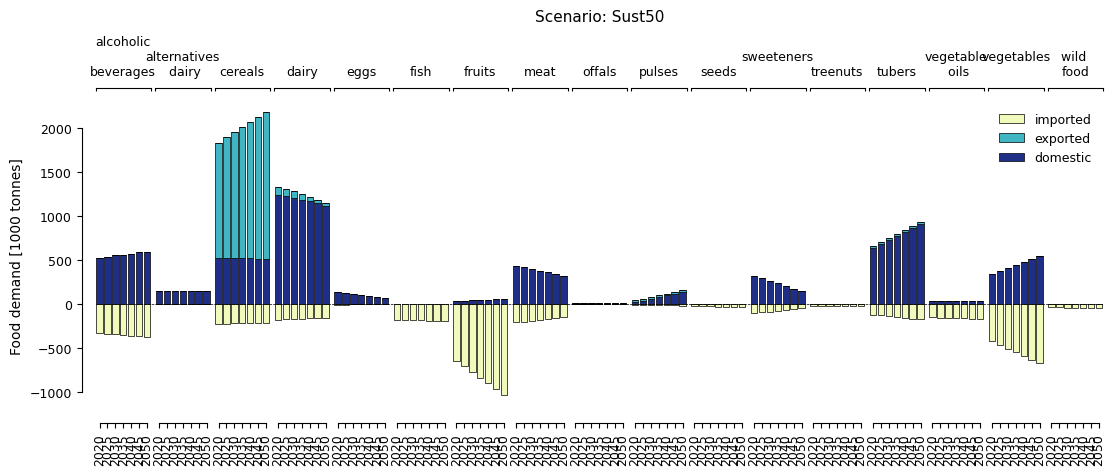

In [20]:
plot_data = (
    session.get_attr(
        module='D',
        attr='food_demand_to_processing',
        groupby=['origin','food_group']
    ).add(
        session.get_attr(
            module='D',
            attr='export_demand',
            groupby=['origin','food_group']
        ).rename(columns={'domestic':'exported'}),
        fill_value = 0
    )
    .stack()
    .fillna(0)
)/1000000
plot_data.loc[:,'imported'] = -plot_data.loc[:,'imported']

for scn in session.scenarios():
    fig, ax = plt.subplots(figsize=(13,4))
    cm.plot.bar(plot_data.loc[scn], group_levels='food_group', grouptitle=f'Scenario: {scn}', ax=ax,
                ylim=(-1200, 2300), totmarker='none', ylabel='Food demand [1000 tonnes]', **bar_style)
    plt.show()